In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style="whitegrid")

# Tạo folder lưu hình
os.makedirs("../../reports/figures/risk_analysis", exist_ok=True)

# Load nhiều file parquet (2021–2025)
# Load toàn bộ dataset từ partition folder
df = pd.read_parquet("../../data/processed/clean_full")

print("Shape:", df.shape)
print(df["YEAR"].value_counts().sort_index())

Shape: (2525185, 82)
YEAR
2021    361428
2022    537902
2023    538837
2024    547271
2025    539747
Name: count, dtype: int64


In [2]:
rename_cols = {
    # Time
    "YEAR": "Year",
    "MONTH": "Month",
    "DAY_OF_WEEK": "DayOfWeek",
    "DAY_OF_MONTH": "DayOfMonth",
    "FL_DATE": "FlightDate",

    # Airline
    "OP_CARRIER": "Airline",
    "OP_UNIQUE_CARRIER": "Airline_Code",

    # Airport
    "ORIGIN": "Origin_Airport",
    "DEST": "Destination_Airport",
    "ORIGIN_CITY_NAME": "Origin_City",
    "DEST_CITY_NAME": "Destination_City",

    # Route
    "ROUTE": "Route",
    "DISTANCE": "Distance",

    # Delay
    "ARR_DELAY": "Arrival_Delay",
    "DEP_DELAY": "Departure_Delay",
    "WEATHER_DELAY": "Weather_Delay",
    "CARRIER_DELAY": "Airline_Delay",
    "NAS_DELAY": "NAS_Delay",
    "SECURITY_DELAY": "Security_Delay",
    "LATE_AIRCRAFT_DELAY": "Late_Aircraft_Delay",

    # Time block
    "DEP_TIME_BLK": "Departure_Time_Block",

    # Risk
    "CANCELLATION_CODE": "Cancel_Code",
    "DIV_ARR_DELAY": "Diverted_Arrival_Delay"
}
df = df.rename(columns=rename_cols)
day_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

df["DayOfWeek"] = df["DayOfWeek"].map(day_map)

In [3]:
#split dataset
df_full = df.copy()

df_cancelled = df[df["CANCELLED"] == 1]
df_diverted = df[df["DIVERTED"] == 1]
df_operated = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)]

print("Full:", len(df_full))
print("Cancelled:", len(df_cancelled))
print("Diverted:", len(df_diverted))
print("Operated:", len(df_operated))

Full: 2525185
Cancelled: 83899
Diverted: 5717
Operated: 2435569


## 3.1. Phân tích theo thời gian

- Xu hướng hủy chuyến và chuyển hướng theo năm

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\1729618202.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby("Year")[col].mean()


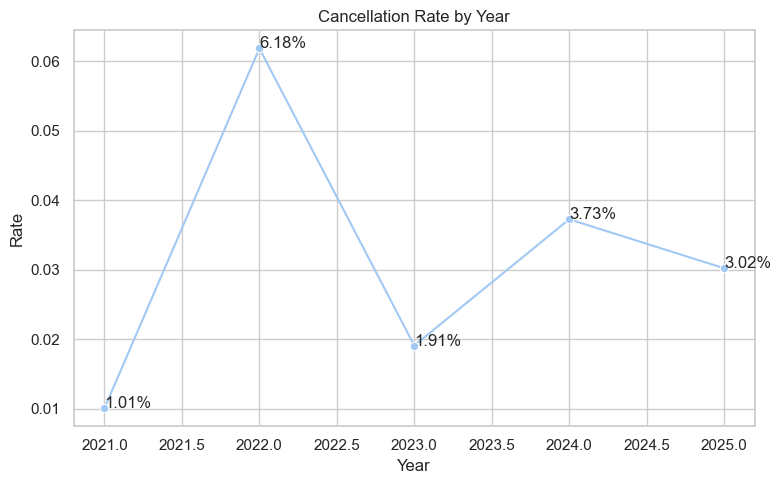

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\1729618202.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby("Year")[col].mean()


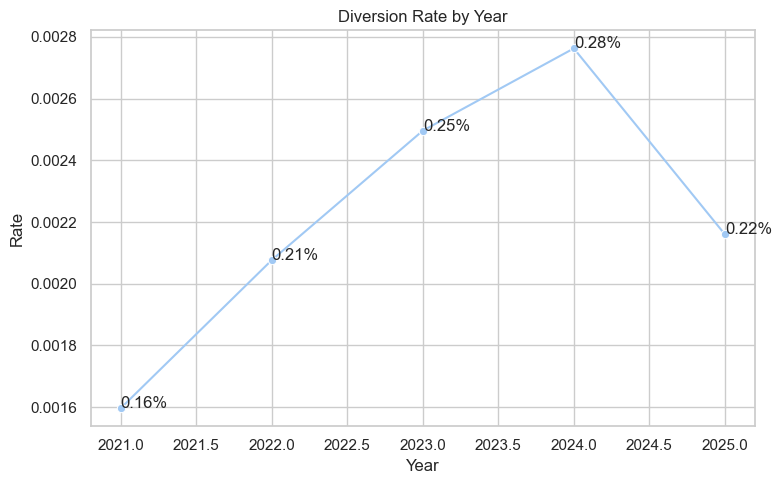

In [4]:
colors_line = sns.color_palette("pastel")
for col, name in [("CANCELLED","Cancellation"), ("DIVERTED","Diversion")]:
    trend = df.groupby("Year")[col].mean()
    plt.figure(figsize=(8,5))
    sns.lineplot(x=trend.index, y=trend.values, marker="o", color=colors_line[0])
    for x,y in zip(trend.index, trend.values):
        plt.text(x, y, f"{y:.2%}")
    plt.title(f"{name} Rate by Year")
    plt.ylabel("Rate")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_year.png")
    plt.show()

- Phân tích theo ngày trong tháng

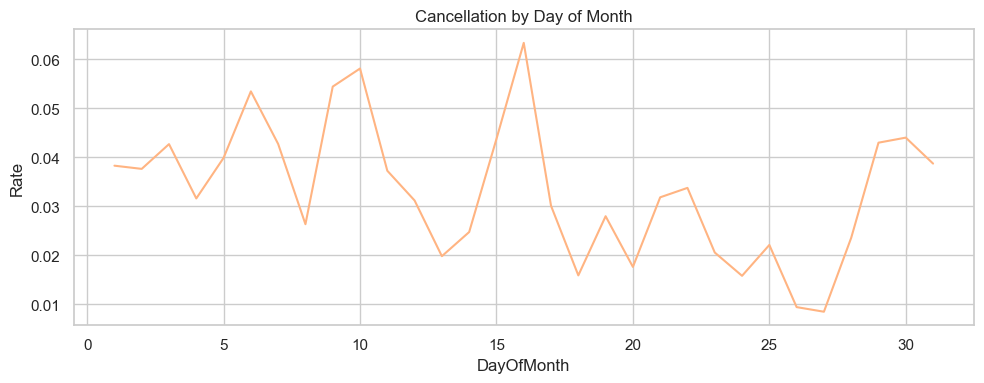

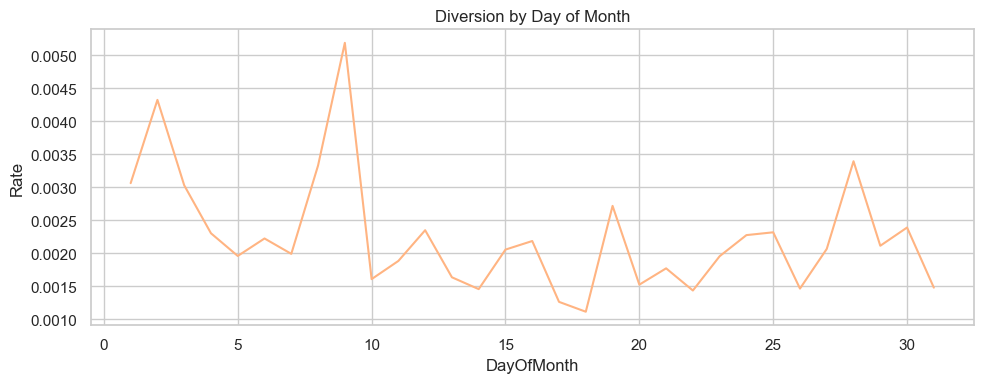

In [5]:
for col, name in [("CANCELLED","Cancellation"), ("DIVERTED","Diversion")]:
    trend = df.groupby("DayOfMonth")[col].mean()
    plt.figure(figsize=(10,4))
    sns.lineplot(x=trend.index, y=trend.values, color=colors_line[1])
    plt.title(f"{name} by Day of Month")
    plt.ylabel("Rate")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_day.png")
    plt.show()

- Phân tích theo ngày trong tuần

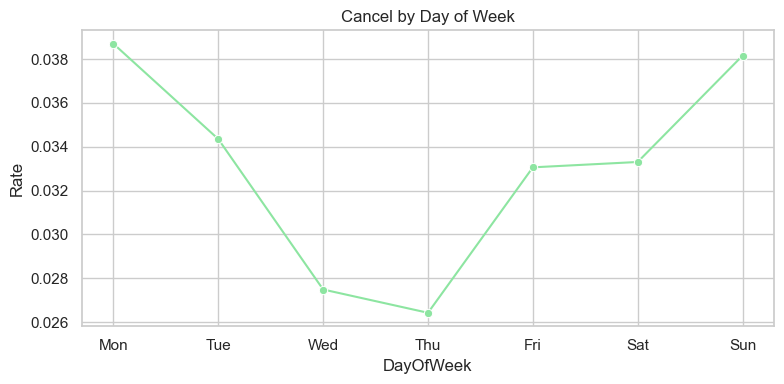

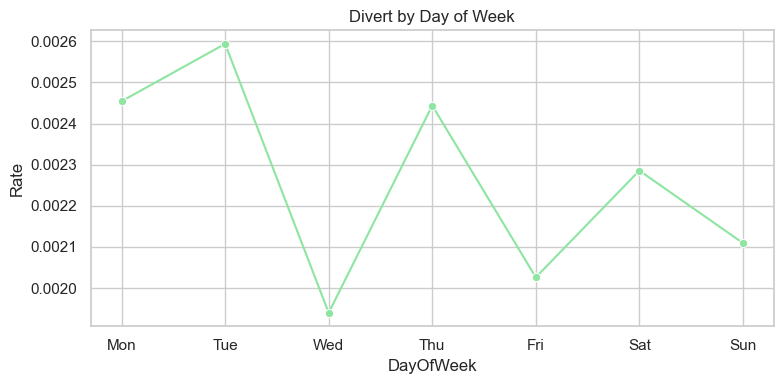

In [6]:
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
for col, label in [("CANCELLED","Cancel"),("DIVERTED","Divert")]:
    trend = df.groupby("DayOfWeek")[col].mean().reindex(order)
    plt.figure(figsize=(8,4))
    sns.lineplot(x=trend.index, y=trend.values, marker="o", color=colors_line[2])
    plt.title(f"{label} by Day of Week")
    plt.ylabel("Rate")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_dow.png")
    plt.show()

- Phân tích theo khung giờ trong ngày

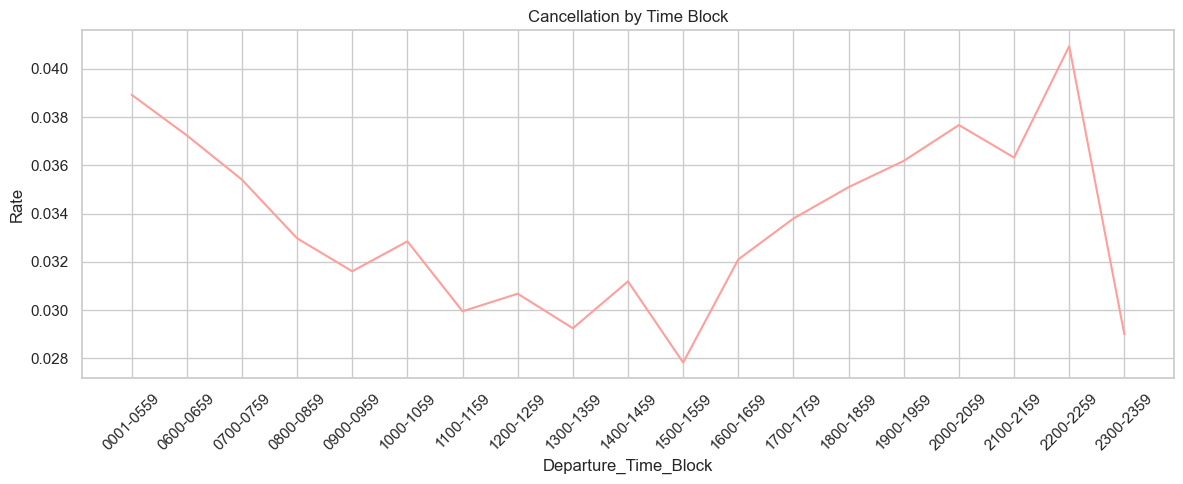

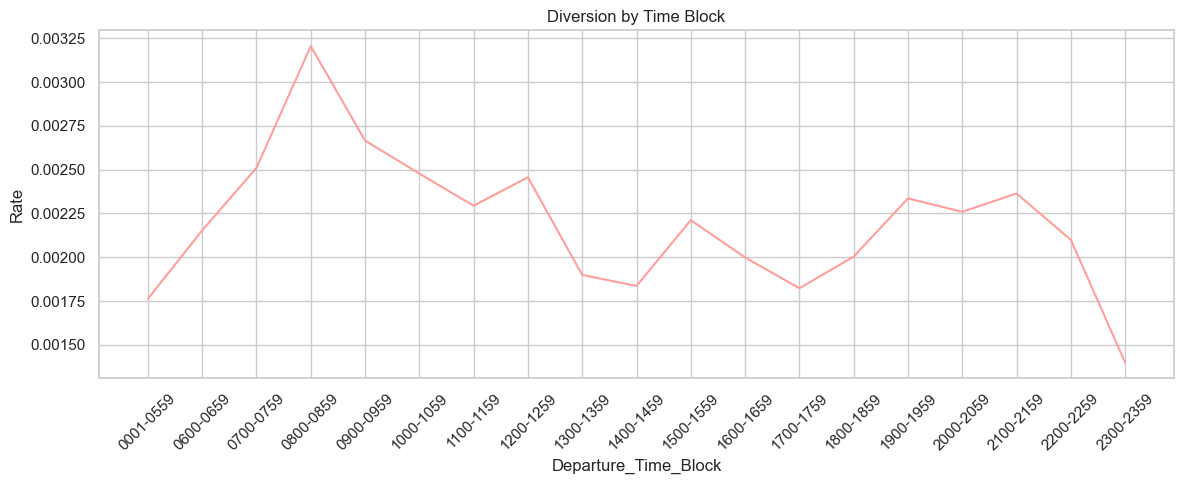

In [7]:
for col, name in [("CANCELLED","Cancellation"), ("DIVERTED","Diversion")]:
    trend = df_full.groupby("Departure_Time_Block")[col].mean().sort_index()
    plt.figure(figsize=(12,5))
    sns.lineplot(x=trend.index, y=trend.values, color=colors_line[3])
    plt.xticks(rotation=45)
    plt.title(f"{name} by Time Block")
    plt.ylabel("Rate")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_timeblock.png")
    plt.show()

3.2. Phân tích theo hãng bay và sân bay

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\2604720602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\2604720602.py:7: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


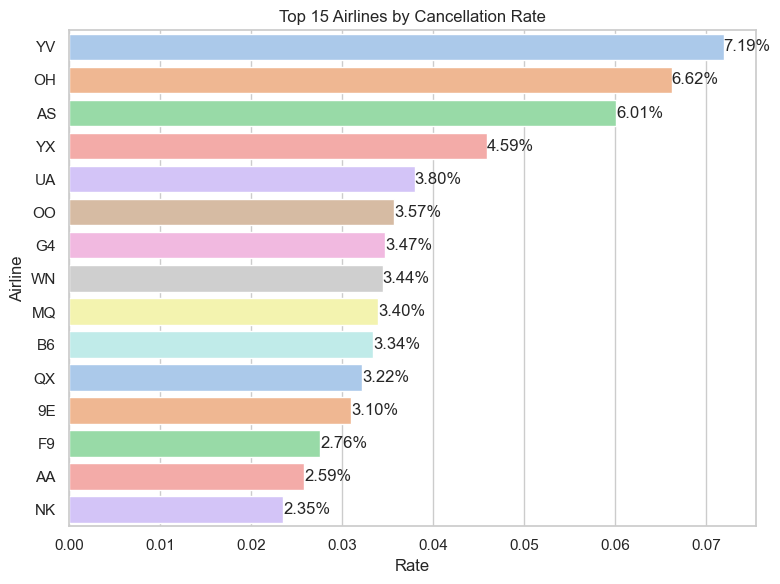

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\2604720602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\2604720602.py:7: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


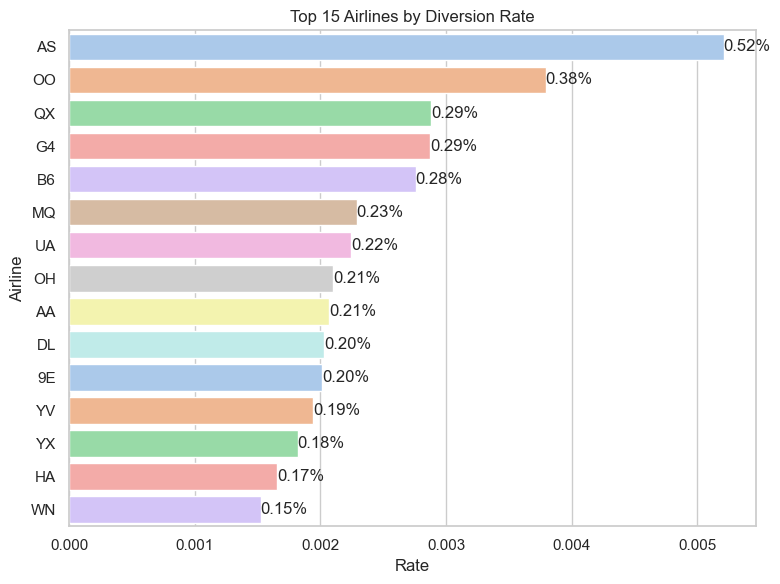

In [8]:
colors_bar = sns.color_palette("pastel")

# Top Airlines
for col, label in [("CANCELLED","Cancellation"), ("DIVERTED","Diversion")]:
    data = df_full.groupby("Airline")[col].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(x=data.values, y=data.index, palette=colors_bar)
    for i,v in enumerate(data.values):
        plt.text(v, i, f"{v:.2%}", va="center")
    plt.title(f"Top 15 Airlines by {label} Rate")
    plt.xlabel("Rate")
    plt.ylabel("Airline")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_airline.png")
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\987044500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\987044500.py:5: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


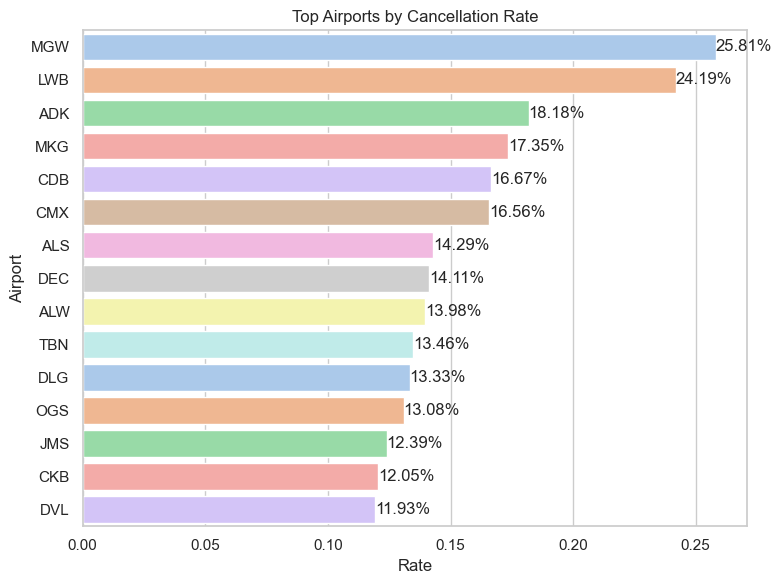

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\987044500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\987044500.py:5: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


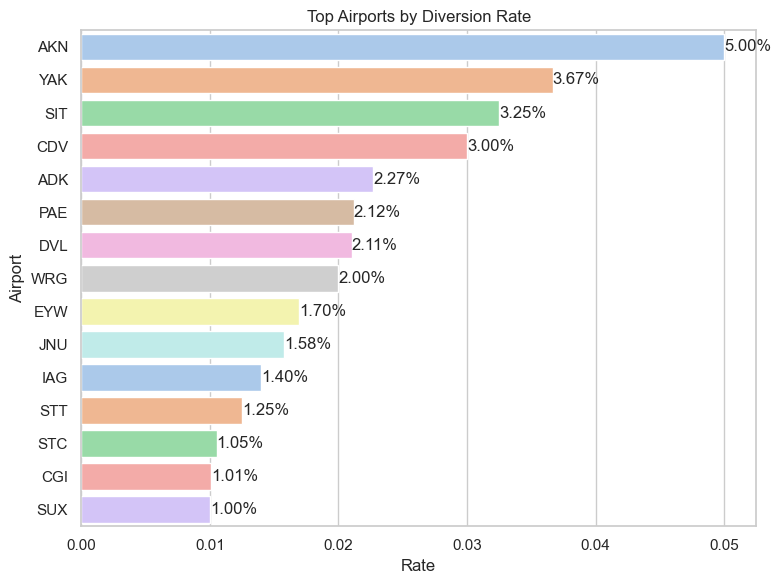

In [9]:

# Top Airports
for col, label in [("CANCELLED","Cancellation"), ("DIVERTED","Diversion")]:
    data = df_full.groupby("Origin_Airport")[col].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(x=data.values, y=data.index, palette=colors_bar)
    for i,v in enumerate(data.values):
        plt.text(v, i, f"{v:.2%}", va="center")
    plt.title(f"Top Airports by {label} Rate")
    plt.xlabel("Rate")
    plt.ylabel("Airport")
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/risk_analysis/{col}_airport.png")
    plt.show()

3.3. Phân tích nguyên nhân rủi ro

- Nguyên nhân hủy chuyến

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\317059873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cancelled["Cancel_Reason"] = df_cancelled["Cancel_Code"].map(reason_map)


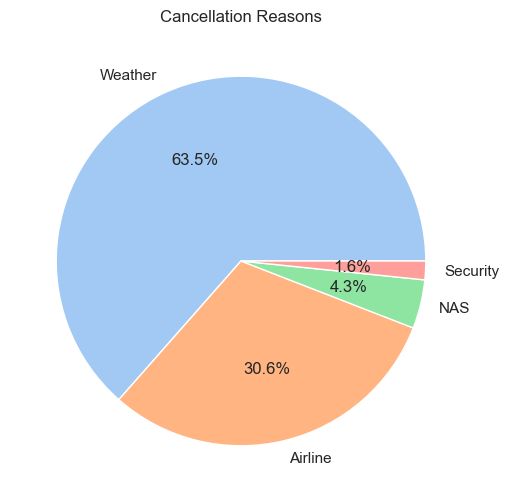

In [10]:
reason_map = {"A":"Airline","B":"Weather","C":"NAS","D":"Security"}
df_cancelled["Cancel_Reason"] = df_cancelled["Cancel_Code"].map(reason_map)
reason_dist = df_cancelled["Cancel_Reason"].value_counts(normalize=True)
plt.figure(figsize=(6,6))
plt.pie(reason_dist.values, labels=reason_dist.index, autopct="%1.1f%%", colors=colors_bar)
plt.title("Cancellation Reasons")
plt.savefig("../../reports/figures/risk_analysis/cancel_reason.png")
plt.show()

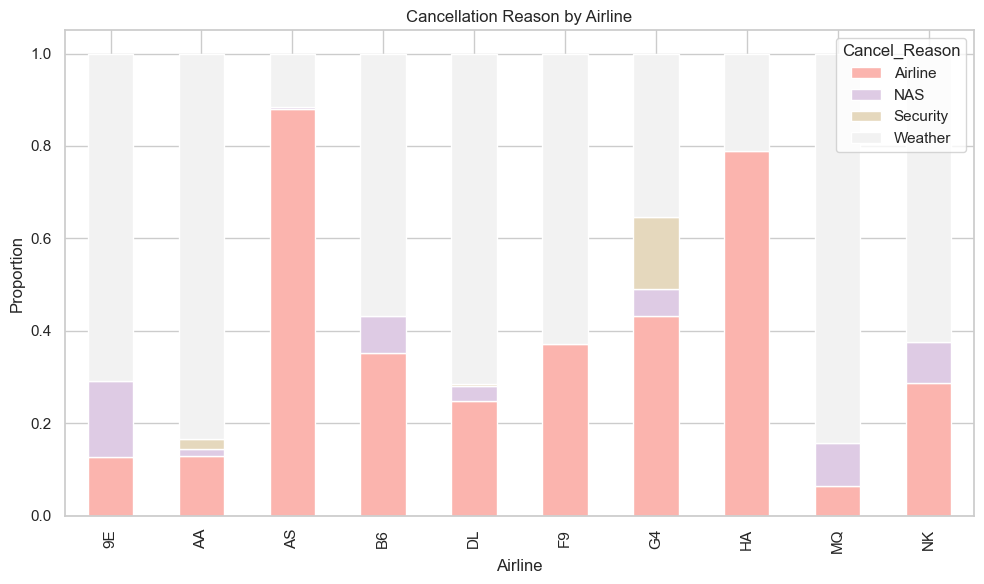

In [11]:
cancel_reason_airline = pd.crosstab(df_cancelled["Airline"], df_cancelled["Cancel_Reason"], normalize="index")
cancel_reason_airline.head(10).plot(kind="bar", stacked=True, figsize=(10,6), colormap="Pastel1")
plt.title("Cancellation Reason by Airline")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/cancel_reason_airline.png")
plt.show()

3.4. Phân tích tác động (Impact Analysis)

- So sánh delay

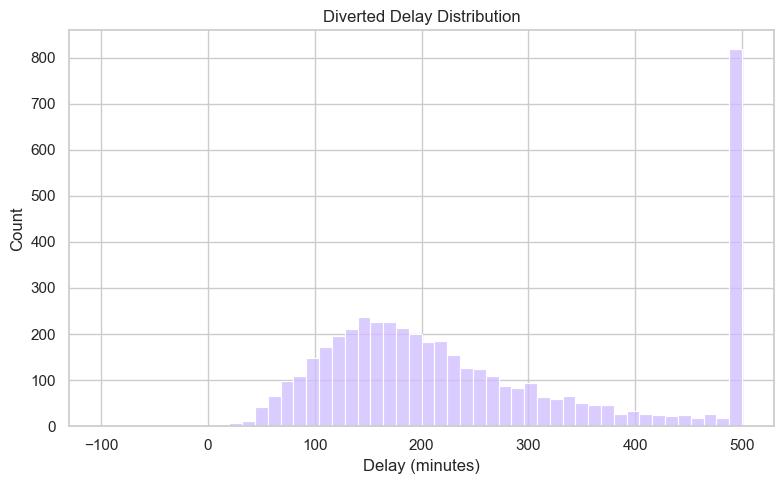

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_diverted["Diverted_Arrival_Delay"].clip(-100,500), bins=50, color=colors_line[4])
plt.title("Diverted Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/divert_dist.png")
plt.show()

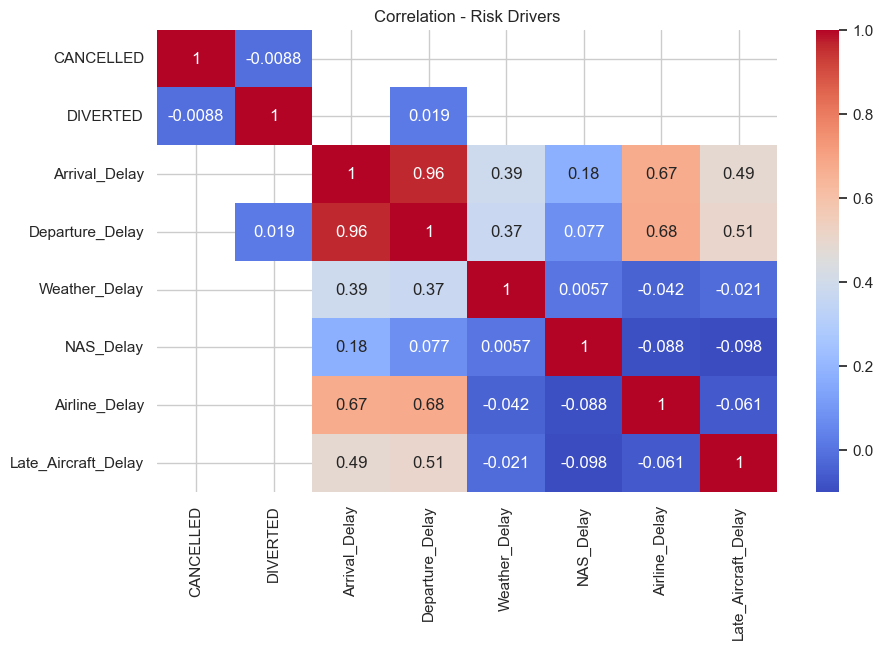

In [13]:

cols = [
    "CANCELLED","DIVERTED",
    "Arrival_Delay","Departure_Delay",
    "Weather_Delay","NAS_Delay",
    "Airline_Delay","Late_Aircraft_Delay"
]

corr = df[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation - Risk Drivers")
plt.savefig("../../reports/figures/risk_analysis/corr.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\3919849893.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_risk = df_full.groupby("Distance_Bin")["CANCELLED"].mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\3919849893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distance_risk.index, y=distance_risk.values, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\3919849893.py:5: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=distance_risk.index, y=distance_risk.values, palette=colors_bar)


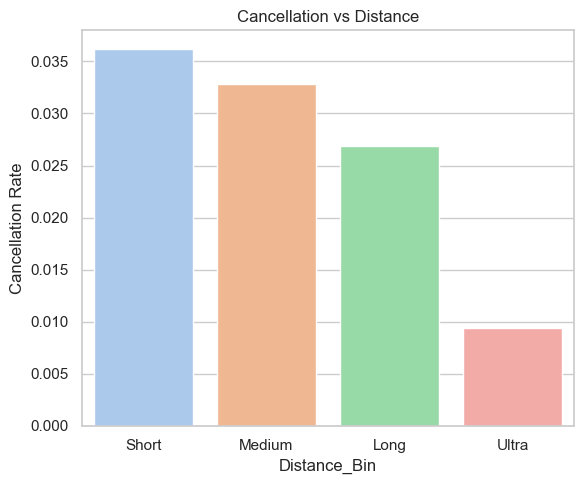

In [14]:
df_full["Distance_Bin"] = pd.cut(df_full["Distance"], bins=[0,500,1500,3000,10000],
                                 labels=["Short","Medium","Long","Ultra"])
distance_risk = df_full.groupby("Distance_Bin")["CANCELLED"].mean()
plt.figure(figsize=(6,5))
sns.barplot(x=distance_risk.index, y=distance_risk.values, palette=colors_bar)
plt.title("Cancellation vs Distance")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

- Tắc nghẽn sân bay - không lưu (NAS)

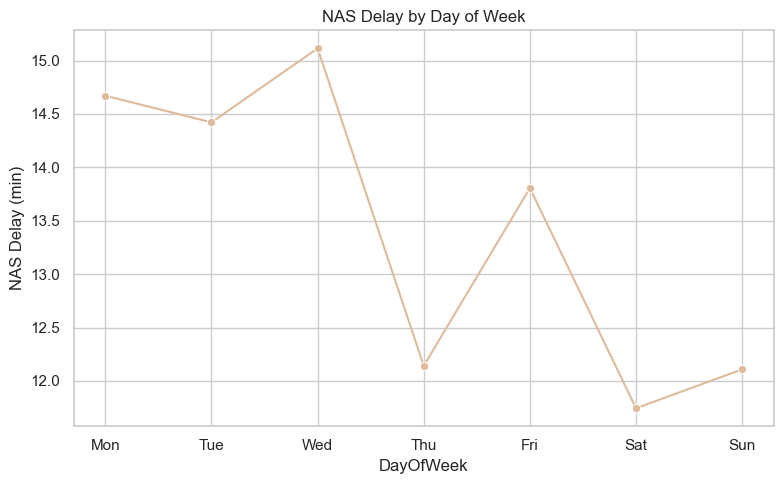

In [15]:
# NAS Delay by Day & Time
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
nas_time = df.groupby("DayOfWeek")["NAS_Delay"].mean().reindex(order)
plt.figure(figsize=(8,5))
sns.lineplot(x=nas_time.index, y=nas_time.values, marker="o", color=colors_line[5])
plt.title("NAS Delay by Day of Week")
plt.ylabel("NAS Delay (min)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/nas_by_day.png")
plt.show()

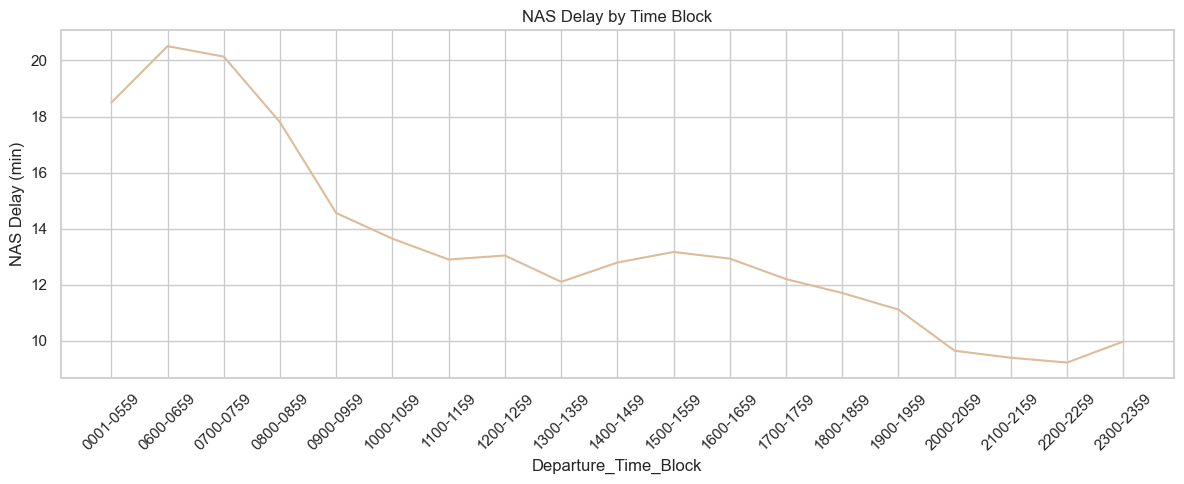

In [16]:
nas_time_blk = df.groupby("Departure_Time_Block")["NAS_Delay"].mean().sort_index()
plt.figure(figsize=(12,5))
sns.lineplot(x=nas_time_blk.index, y=nas_time_blk.values, color=colors_line[5])
plt.xticks(rotation=45)
plt.title("NAS Delay by Time Block")
plt.ylabel("NAS Delay (min)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/nas_by_time.png")
plt.show()

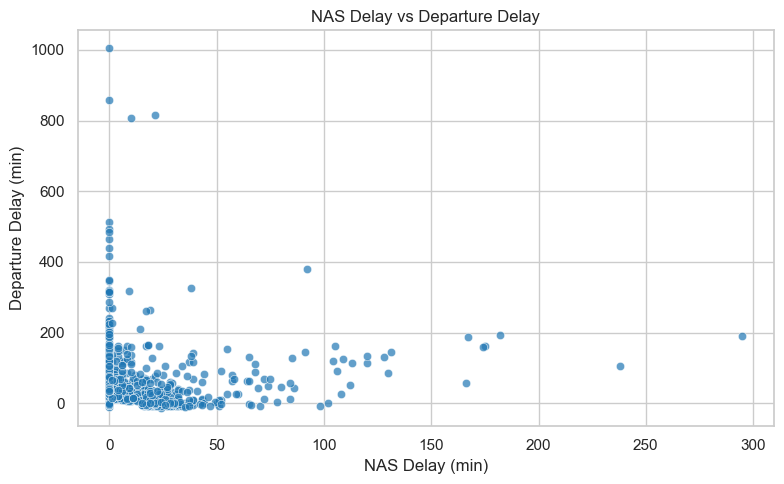

In [17]:
# NAS vs Departure Delay Scatter
sample_df = df.sample(5000)
plt.figure(figsize=(8,5))
sns.scatterplot(x=sample_df["NAS_Delay"], y=sample_df["Departure_Delay"], alpha=0.7, color="#1f77b4")
plt.title("NAS Delay vs Departure Delay")
plt.xlabel("NAS Delay (min)")
plt.ylabel("Departure Delay (min)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/scatter_nas_delay.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\942073214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\942073214.py:3: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=top_routes.values, y=top_routes.index, palette=colors_bar)


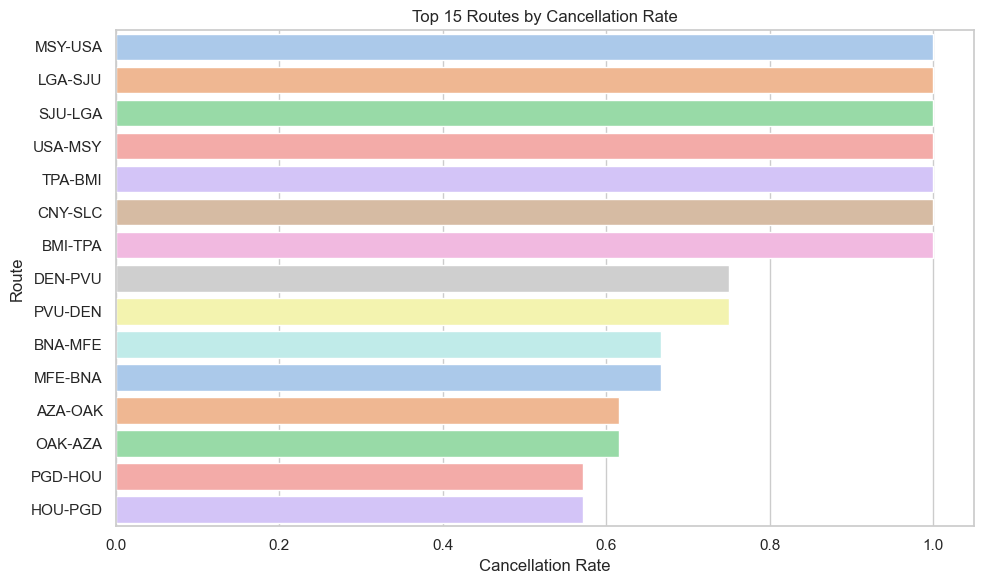

In [18]:
top_routes = df_full.groupby("Route")["CANCELLED"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette=colors_bar)
plt.title("Top 15 Routes by Cancellation Rate")
plt.xlabel("Cancellation Rate")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_844\3332064353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes_div.values, y=top_routes_div.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_844\3332064353.py:3: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=top_routes_div.values, y=top_routes_div.index, palette=colors_bar)


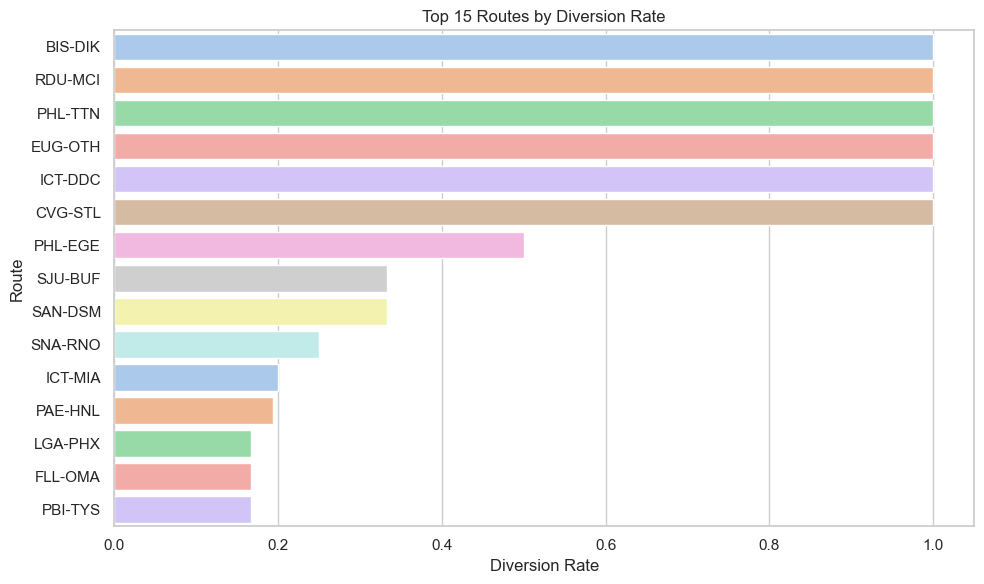

In [19]:
top_routes_div = df_full.groupby("Route")["DIVERTED"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_routes_div.values, y=top_routes_div.index, palette=colors_bar)
plt.title("Top 15 Routes by Diversion Rate")
plt.xlabel("Diversion Rate")
plt.tight_layout()
plt.show()


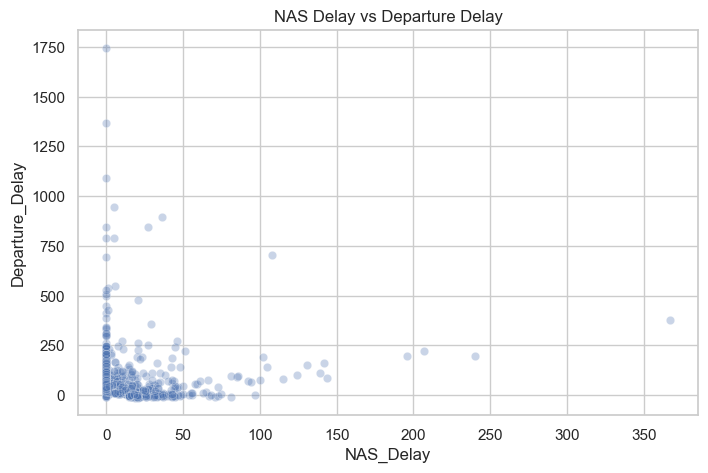

In [20]:
sample_df = df.sample(5000)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=sample_df["NAS_Delay"],
    y=sample_df["Departure_Delay"],
    alpha=0.3
)

plt.title("NAS Delay vs Departure Delay")
plt.savefig("../../reports/figures/risk_analysis/scatter_nas_delay.png")
plt.show()

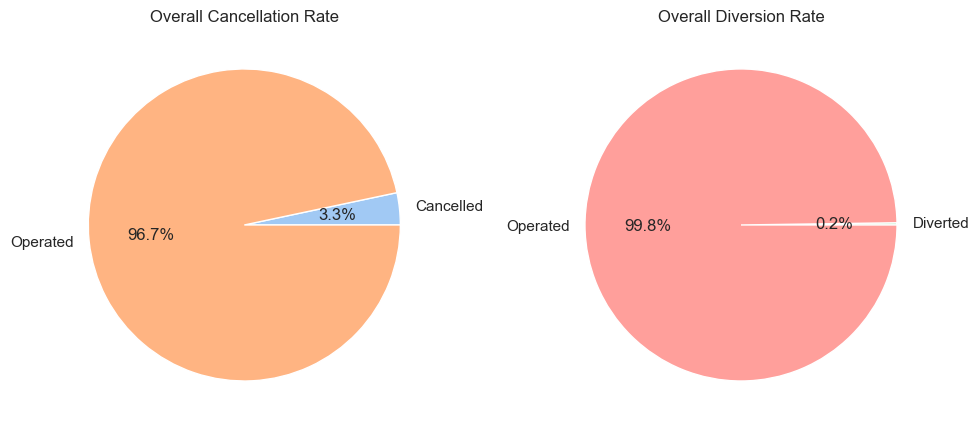

In [21]:
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].pie([df_full["CANCELLED"].mean(), 1-df_full["CANCELLED"].mean()],
            labels=["Cancelled","Operated"], autopct="%1.1f%%", colors=colors_bar[:2])
axes[0].set_title("Overall Cancellation Rate")

axes[1].pie([df_full["DIVERTED"].mean(), 1-df_full["DIVERTED"].mean()],
            labels=["Diverted","Operated"], autopct="%1.1f%%", colors=colors_bar[2:4])
axes[1].set_title("Overall Diversion Rate")

plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/overall_cancel_divert.png")
plt.show()